In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.subtyping_em_transformer import SubtypingEM

np.set_printoptions(precision=4)

In [2]:
# data params
n_biomarkers = 3
t_max = 15 # was 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.0
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 2 #3,4,5
rng = np.random.RandomState(75)

For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.

SUBTYPE 0:
f: [0.  0.  0.3]
a = 4.676436127196727, b = 6.421955999238555


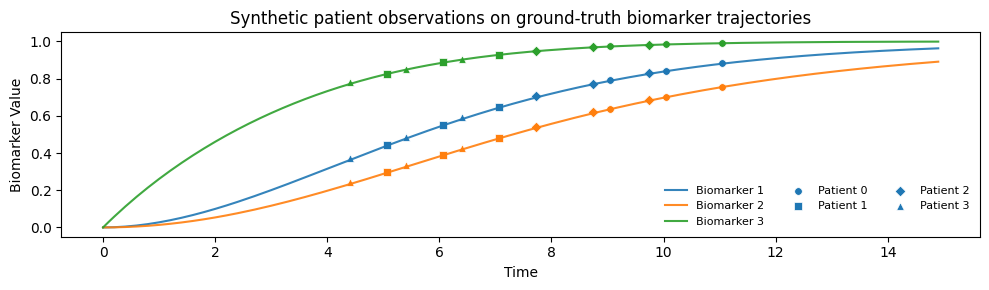

6.202801039330404
SUBTYPE 1:
f: [0.2 0.  0. ]
a = 1.1927249100009507, b = 6.8096301386771785


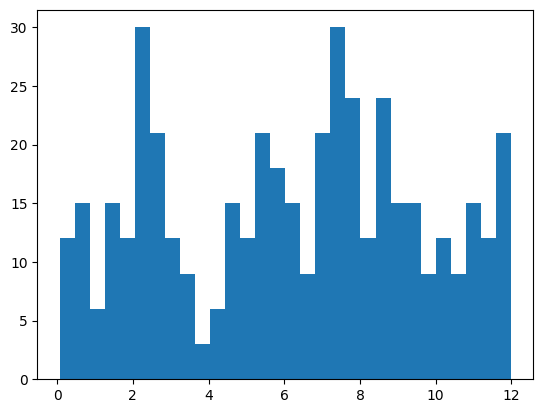

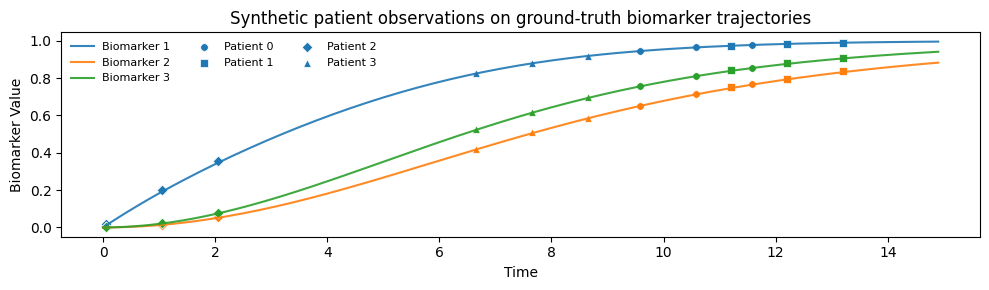

5.825679146677601


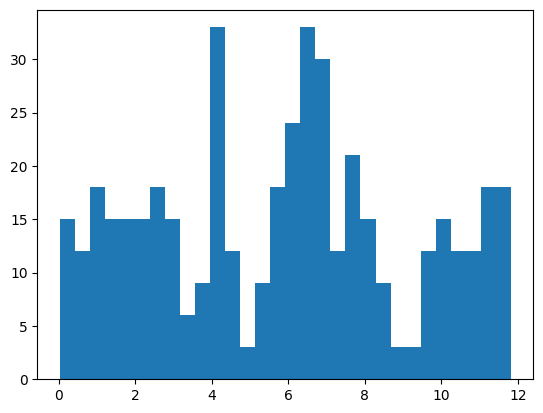

In [3]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.2, 0.2]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

f_list = [np.array([0.0, 0.0, 0.3]), np.array([0.2, 0.0, 0.0])]

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype + 2),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    #print(f"dt shape: {dt.shape}\nids shape: {ids.shape}\ncog shape: {cog.shape}\nbeta shape: {beta_true.shape}")
    #print(beta_true)

    plt.hist(beta_true, bins=30)
    print(np.mean(beta_true))
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    #  print(beta_true[::n_patient_obs][0:10])
    
X = np.asarray(X)
y = np.concatenate(y)

# print(len(X))
# print(len(y))#, y)
# print(y)

In [4]:
all_dt = np.concatenate([p["dt"] for p in X])
all_cog = np.concatenate([p["cog"] for p in X])
all_ids_array = np.concatenate([[p["id"]] * len(p["dt"]) for p in X])

initial_beta, pid_to_beta, result = fit_mixedlm_beta_from_clinical(
    ids=all_ids_array,
    dt=all_dt,
    cog=all_cog,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

unique_ids = np.unique([p["id"] for p in X])
beta_true_array = y
        
print(f"Initialized beta for {len(initial_beta)} patients")
print(f"Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"True beta range: [{np.min(beta_true_array):.2f}, {np.max(beta_true_array):.2f}]")


β_init summary: count    300.000000
mean       6.344669
std        4.981367
min        0.000000
25%        2.478340
50%        4.343781
75%       11.185657
max       15.000000
dtype: float64
Initialized beta for 300 patients
Beta range: [0.00, 15.00]
True beta range: [0.02, 11.98]


## fit() Call

The SubtypingEM algorithm performs:
1. Global s parameter estimation
2. Cluster assignment (hard assignment for now)
3. Cluster-level f and scalar_K estimation
4. Patient-level beta estimation

In [5]:
f_init = initialize_f_eigen(K=K)
if isinstance(f_init, list):
    f_init = f_init[0]

# Add initial_beta to patient data (from cell 4)
unique_ids = np.unique([p["id"] for p in X])
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
for p in X:
    p["initial_beta"] = initial_beta[id_to_beta_idx[p["id"]]]


In [6]:
subtyping_em = SubtypingEM(
    K=K,
    initial_f=f_init,
    n_subtypes=n_subtypes,
    jac_toggle=True,
    max_iter=1000,
    t_max=t_max,
    step=0.01,
    epsilon=1e-4,
    lambda_f=1.0,
    lambda_cog=0.0,
    lambda_scalar=20.0,
    lambda_jsd=0.0,  # JSD prevents beta clumping (0 to disable)
    verbose=1,
    lambda_beta=0.18,
    rng=np.random.default_rng(75)
)

subtyping_em.fit(X)

  1%|          | 10/1000 [01:40<2:45:01, 10.00s/it]


SubtypingEM(K=array([[0.    , 0.6422, 1.    ],
       [0.6422, 0.    , 0.4611],
       [1.    , 0.4611, 0.    ]]),
            epsilon=0.0001, initial_f=array([[0.6021, 0.4866, 0.6256]]),
            jac_toggle=True, lambda_beta=0.18, lambda_cog=0.0, lambda_f=1.0,
            lambda_scalar=20.0, max_iter=1000,
            rng=Generator(PCG64) at 0x7FB752800C80, t_max=15)

In [7]:
subtyping_em.compute_subtype_mapping(f_list, verbose=True)
subtype_mapping = subtyping_em.subtype_mapping # store for plotting later

print_parameter_comparison(
    fitted_f_list=subtyping_em.cluster_f,
    fitted_scalar_K=subtyping_em.final_scalar_K,
    fitted_s=subtyping_em.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),  # s is typically all ones in synthetic data
    subtype_mapping=subtyping_em.subtype_mapping,
    n_subtypes=n_subtypes,
)

# Confusion matrix for single fit
from sklearn.metrics import confusion_matrix
assignments_true = np.array([p["subtype_true"] for p in X])
# Map fitted assignments using subtype mapping
mapped_assignments = subtype_mapping[subtyping_em.final_assignments]
print("\n=== Confusion Matrix: Single Fit (with mapping) ===")
cm_single = confusion_matrix(assignments_true, mapped_assignments)
print(cm_single)


Subtype mapping (fitted -> true): [0 1]
  Fitted subtype 0 -> True subtype 0
  Fitted subtype 1 -> True subtype 1

Fitted Subtype 0 -> True Subtype 0:
  f_fitted:      [0.     0.     0.0082]
  f_true:        [0.  0.  0.3]

Fitted Subtype 1 -> True Subtype 1:
  f_fitted:      [0.8729 0.1446 0.    ]
  f_true:        [0.2 0.  0. ]

Global scalar_K:
  scalar_K_fitted: 0.791578
  scalar_K_true (mean): 0.200000
  scalar_K_true (per subtype): [0.2, 0.2]

Global s:
  s_fitted:      [0.8767 0.6832 0.9522]
  s_true:        [1. 1. 1.]

=== Confusion Matrix: Single Fit (with mapping) ===
[[111  39]
 [ 78  72]]


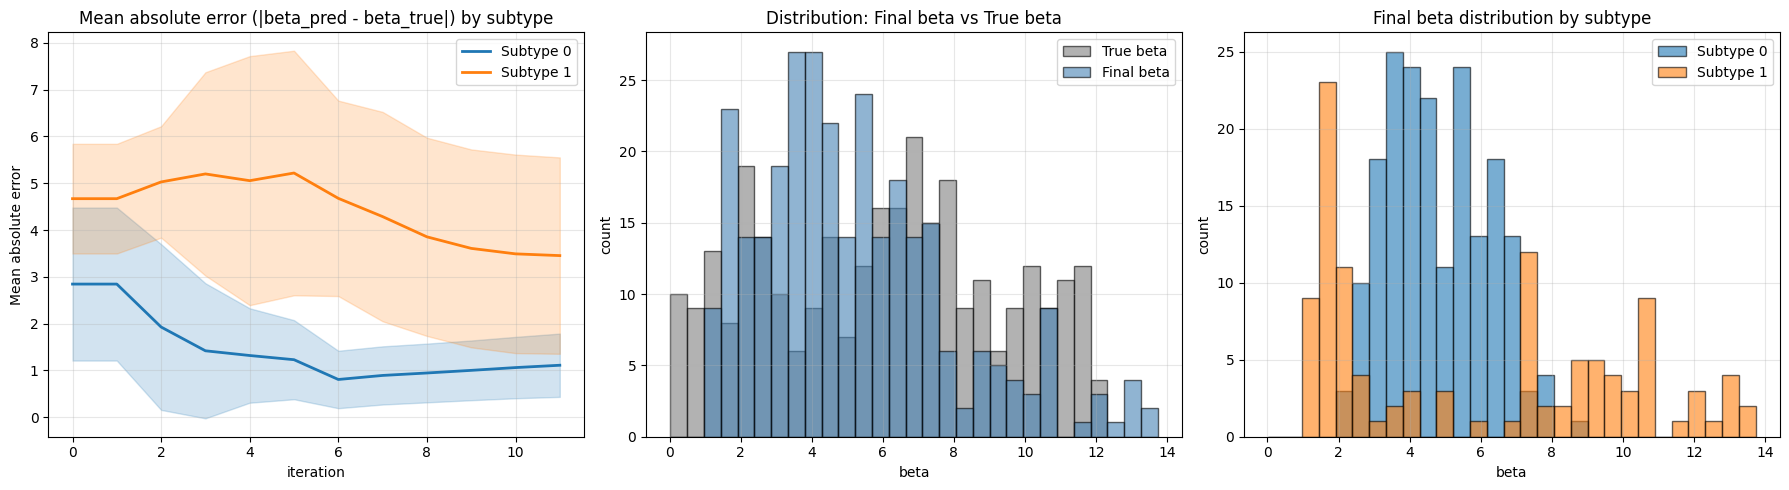

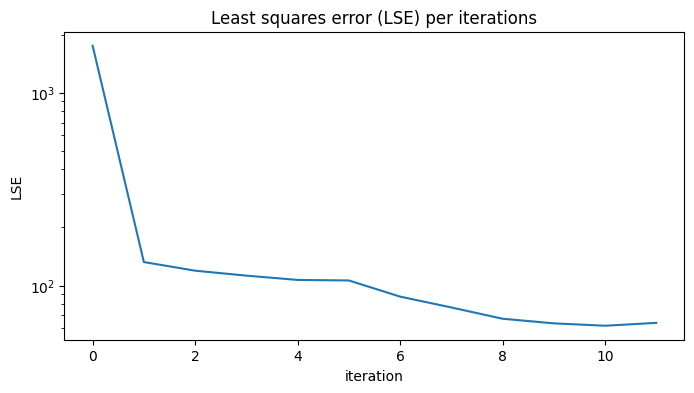

In [8]:
plot_beta_history_by_subtype(
    beta_history=subtyping_em.beta_history,
    assignments=subtyping_em.final_assignments,
    n_subtypes=n_subtypes,
    beta_true=beta_true_array,
    subtype_mapping=subtype_mapping if 'subtype_mapping' in locals() else None,
)



plot_lse(subtyping_em.lse_history)

## Multiple Initializations

Run multiple EM fits with different random initial cluster assignments in parallel to assess stability and convergence.


In [9]:
from EMDPM.subtyping_em_transformer import run_multiple_initializations_parallel

# Prepare EM kwargs (same as single fit)
em_kwargs = {
    'K': K,
    'initial_f': f_init,
    'n_subtypes': n_subtypes,
    'jac_toggle': True,
    'max_iter': 1000,
    't_max': t_max,
    'step': 0.01,
    'epsilon': 5e-2,
    'lambda_f': 0.5,
    'lambda_cog': 0.0,
    'lambda_scalar': 0.3,
    'lambda_jsd': 0.0,
    'verbose': 0,
    'lambda_beta': 0.15,
}

# Run multiple initializations in parallel
# Returns: results (list of all fitted models) and best_idx (index of best one)
n_initializations = 20
print(f"Running {n_initializations} initializations in parallel...")

results, best_idx = run_multiple_initializations_parallel(
    X=X,
    n_initializations=n_initializations,
    em_kwargs=em_kwargs,
    n_jobs=-1,  # Use all available cores mwahahahahaha
    prefer="processes",
    seed_offset=0,
    rng=np.random.default_rng(75)
)

print(f"\nCompleted {len(results)} initializations")
print(f"Best initialization (lowest final LSE): {best_idx}")
print(f"Best final LSE: {results[best_idx]['final_lse']:.6f}")

Running 20 initializations in parallel...



Completed 20 initializations
Best initialization (lowest final LSE): 12
Best final LSE: 29.505589


In [10]:
# Compare best model with single fit
from sklearn.metrics import adjusted_rand_score, confusion_matrix, classification_report
best_model = results[best_idx]['model']

# Get ground truth assignments (needed for ARI calculation)
assignments_true = np.array([p["subtype_true"] for p in X])
best_model.compute_subtype_mapping(f_list, verbose=True)

# Print parameter comparison for best model
print_parameter_comparison(
    fitted_f_list=best_model.cluster_f,
    fitted_scalar_K=best_model.final_scalar_K,
    fitted_s=best_model.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),  # s is typically all ones in synthetic data
    subtype_mapping=best_model.subtype_mapping,
    n_subtypes=n_subtypes,
)

best_model_subtype_mapping = best_model.subtype_mapping

# Confusion matrix for best model
from sklearn.metrics import confusion_matrix
# Map fitted assignments using subtype mapping
mapped_assignments_best = best_model_subtype_mapping[best_model.final_assignments]
print("\nConfusion Matrix: Best Model (with mapping)")
cm_best = confusion_matrix(assignments_true, mapped_assignments_best)
print(cm_best)



Subtype mapping (fitted -> true): [0 1]
  Fitted subtype 0 -> True subtype 0
  Fitted subtype 1 -> True subtype 1

Fitted Subtype 0 -> True Subtype 0:
  f_fitted:      [0.     0.     0.1521]
  f_true:        [0.  0.  0.3]

Fitted Subtype 1 -> True Subtype 1:
  f_fitted:      [0.1556 0.     0.    ]
  f_true:        [0.2 0.  0. ]

Global scalar_K:
  scalar_K_fitted: 0.348207
  scalar_K_true (mean): 0.200000
  scalar_K_true (per subtype): [0.2, 0.2]

Global s:
  s_fitted:      [1.0111 0.8547 0.9073]
  s_true:        [1. 1. 1.]

Confusion Matrix: Best Model (with mapping)
[[150   0]
 [  0 150]]


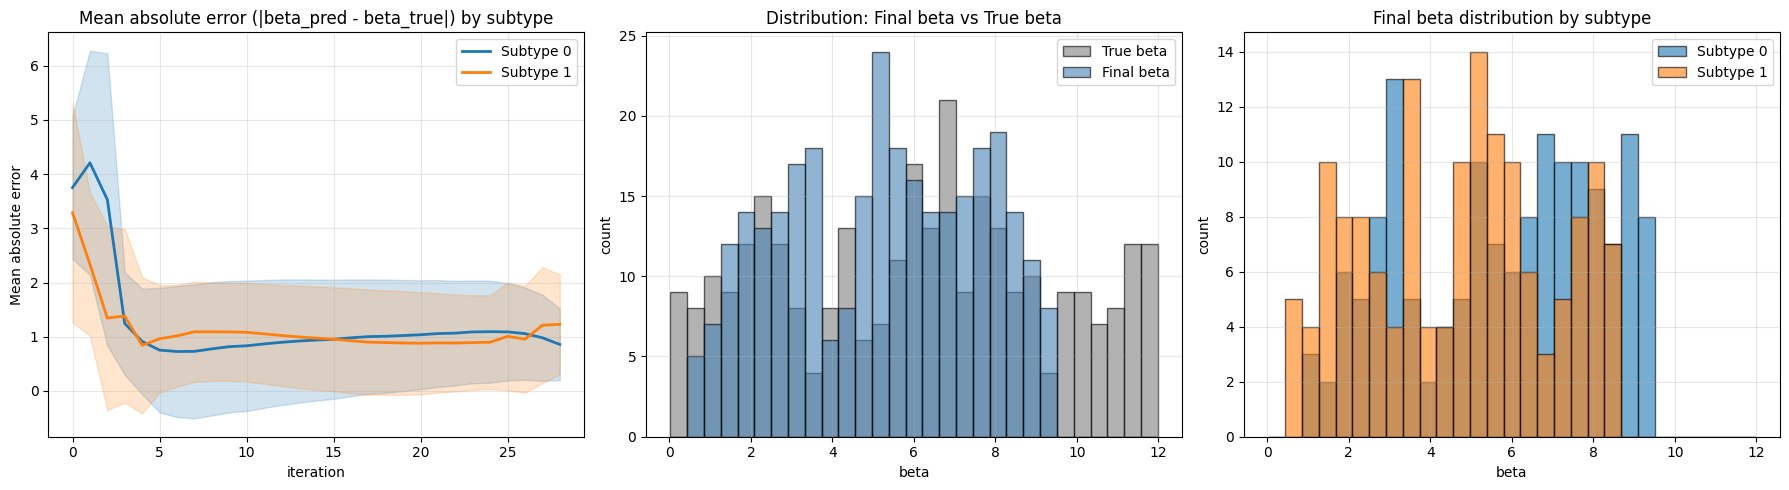

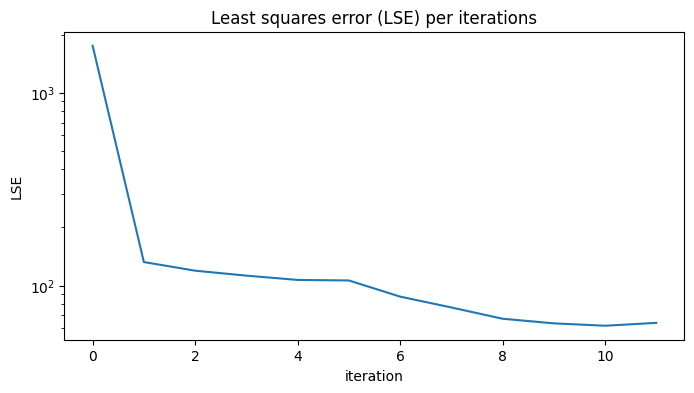

In [11]:
plot_beta_history_by_subtype(
    beta_history=best_model.beta_history,
    assignments=best_model.final_assignments,
    n_subtypes=n_subtypes,
    beta_true=beta_true_array,
    subtype_mapping=subtype_mapping if 'subtype_mapping' in locals() else None,
)

plot_lse(subtyping_em.lse_history)

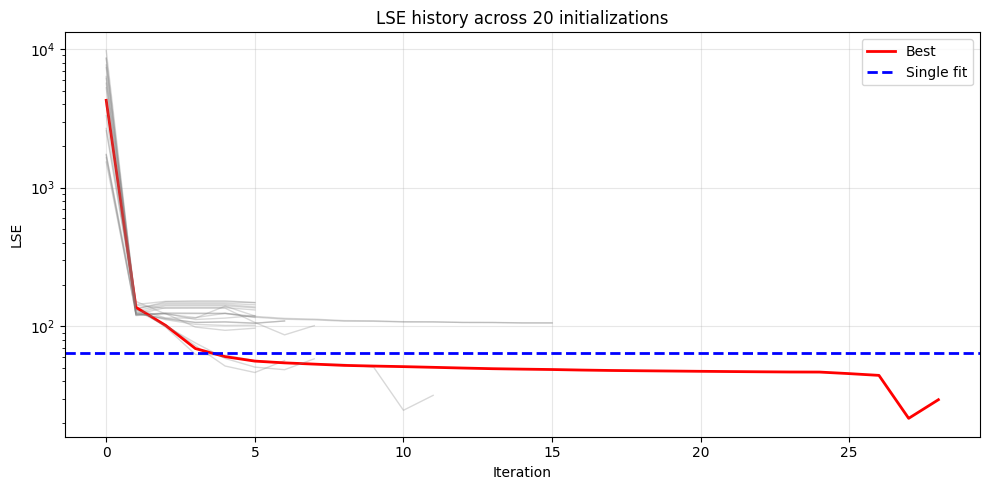

In [12]:
# Plot LSE history for all initializations
plt.figure(figsize=(10, 5))
for i, result in enumerate(results):
    lse_history = result['lse_history']
    color = 'red' if i == best_idx else 'gray'
    alpha = 1.0 if i == best_idx else 0.3
    linewidth = 2 if i == best_idx else 1
    label = 'Best' if i == best_idx else None
    plt.plot(lse_history, color=color, alpha=alpha, linewidth=linewidth, label=label)

plt.axhline(y=subtyping_em.lse_history[-1], color='blue', linestyle='--', linewidth=2, label='Single fit')
plt.xlabel('Iteration')
plt.ylabel('LSE')
plt.title(f'LSE history across {n_initializations} initializations')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cluster Assignment Evaluation

evaluate how well the algorithm recovered the true subtypes.

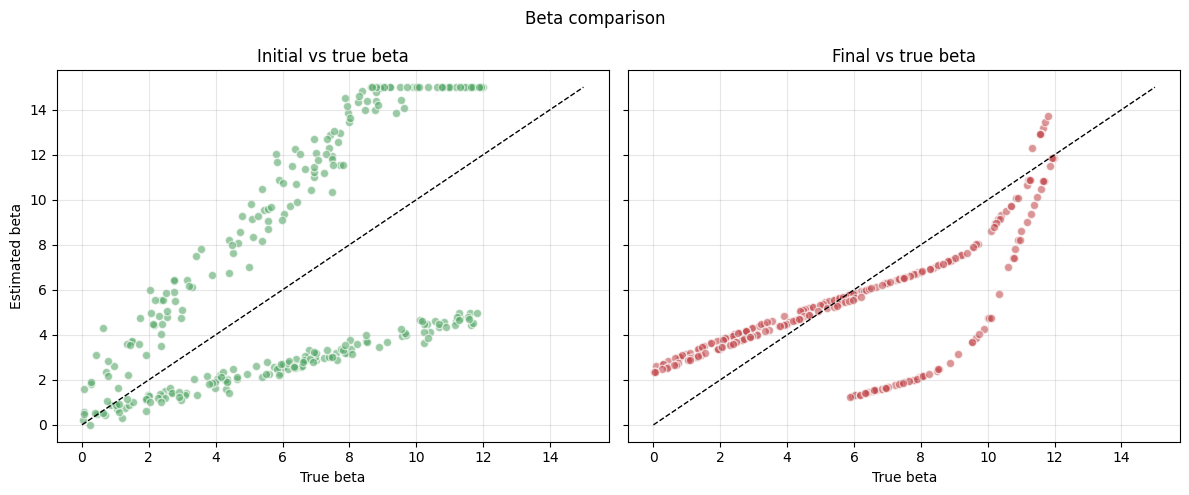

In [14]:
# Plot initial and final beta estimates against true beta
beta_init_array = np.array([p.get("initial_beta", np.nan) for p in X])
if np.any(np.isnan(beta_init_array)):
    # Fallback: use the initial_beta array directly
    beta_init_array = initial_beta

beta_final_array = subtyping_em.beta_history[:, -1]

plot_beta_comparison(beta_true_array, beta_init_array, beta_final_array)

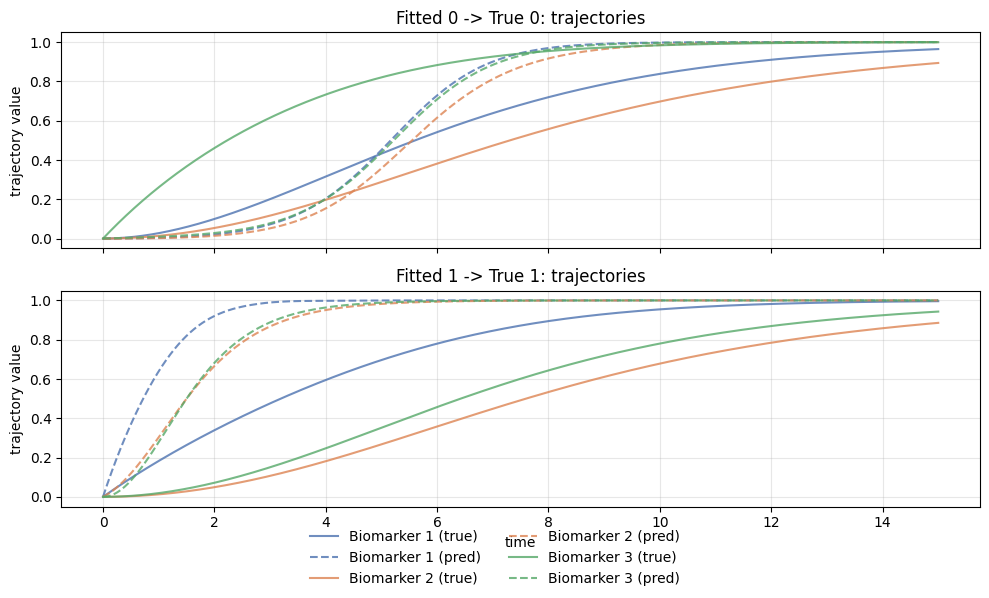

[[111  39]
 [ 78  72]]


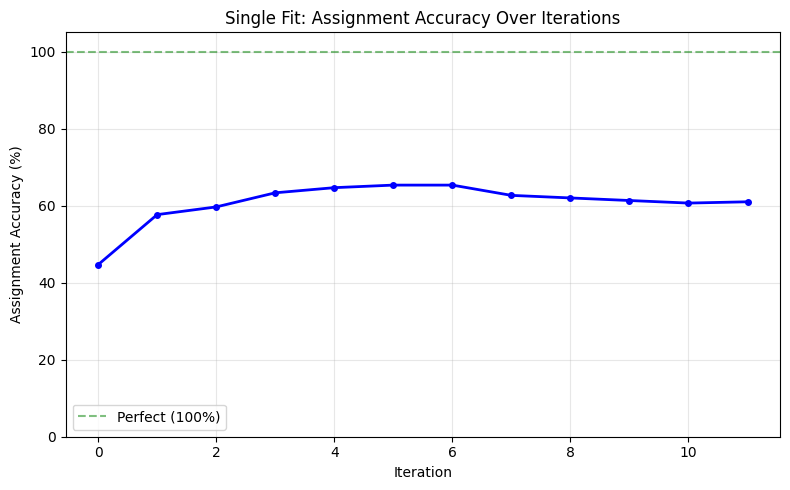

In [15]:
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=subtyping_em.cluster_f,
    scalar_K_pred_list=[subtyping_em.final_scalar_K] * n_subtypes,  # Global scalar_K repeated for each subtype
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=subtype_mapping,
)

# Confusion matrix for single fit
from sklearn.metrics import confusion_matrix
assignments_true = np.array([p["subtype_true"] for p in X])
# Map fitted assignments to true subtypes using subtype_mapping
mapped_assignments = np.array([subtype_mapping[a] for a in subtyping_em.final_assignments])
cm_single = confusion_matrix(assignments_true, mapped_assignments)
print(cm_single)

# Plot assignment accuracy over iterations for single fit
plot_assignment_accuracy_history(
    assignment_history=subtyping_em.assignment_history,
    true_assignments=assignments_true,
    subtype_mapping=subtype_mapping,
    title="Single Fit: Assignment Accuracy Over Iterations",
)



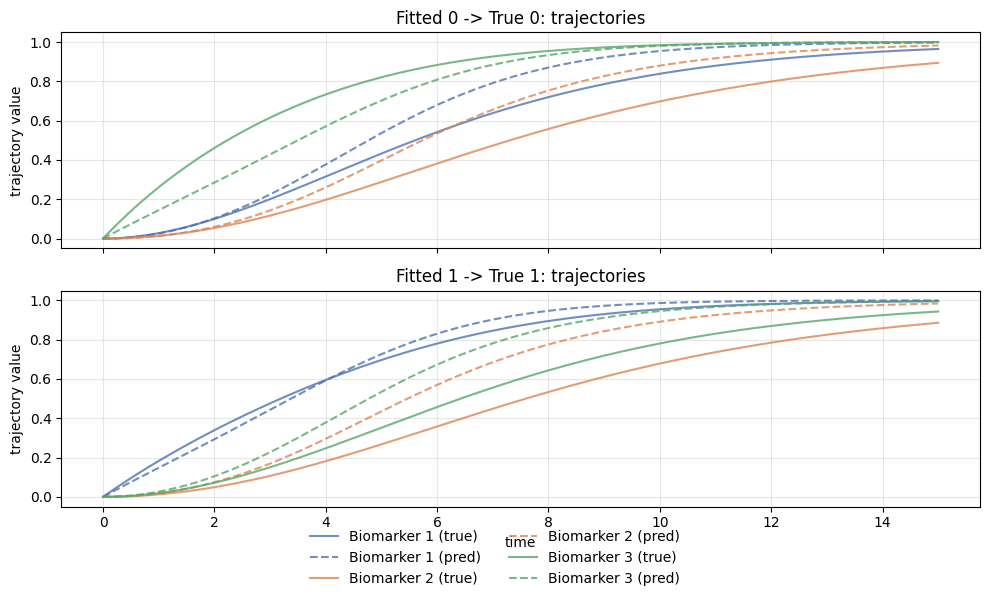

[[150   0]
 [  0 150]]


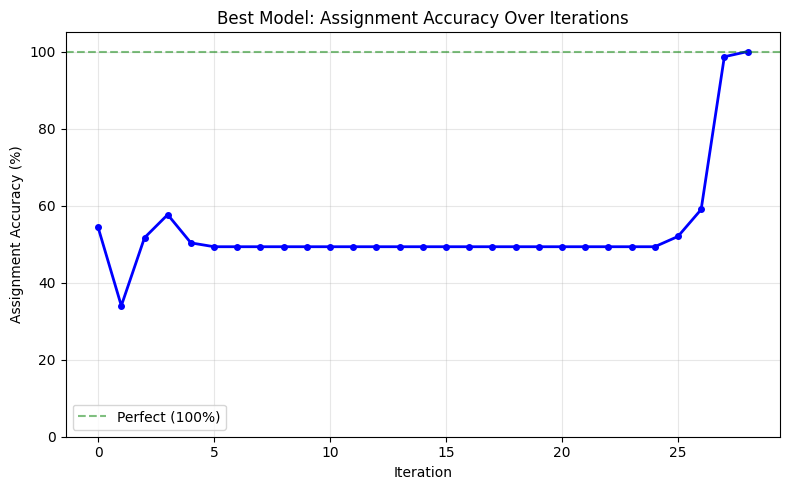

In [16]:
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=best_model.cluster_f,
    scalar_K_pred_list=[best_model.final_scalar_K] * n_subtypes,  # Global scalar_K repeated for each subtype
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=best_model_subtype_mapping,
)

# Confusion matrix for best model
from sklearn.metrics import confusion_matrix
assignments_true = np.array([p["subtype_true"] for p in X])
# Map fitted assignments to true subtypes using subtype_mapping
mapped_assignments_best = np.array([best_model_subtype_mapping[a] for a in best_model.final_assignments])
cm_best = confusion_matrix(assignments_true, mapped_assignments_best)
print(cm_best)

# Plot assignment accuracy over iterations for best model
plot_assignment_accuracy_history(
    assignment_history=best_model.assignment_history,
    true_assignments=assignments_true,
    subtype_mapping=best_model_subtype_mapping,
    title="Best Model: Assignment Accuracy Over Iterations",
)



300
300


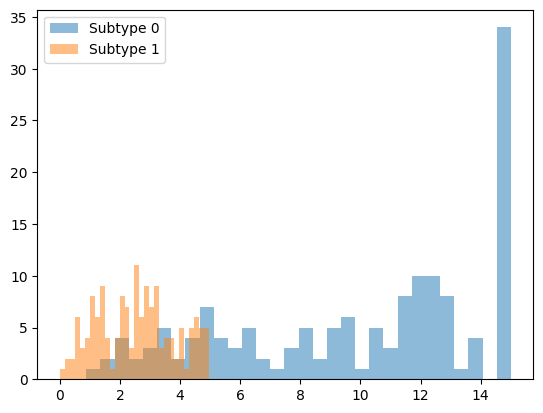

In [17]:
assignments_best=best_model.final_assignments
beta_pred_best=best_model.beta_history[:, 0]

print(len(assignments_best))
print(len(beta_pred_best))

beta0 = beta_pred_best[assignments_best == 0]
beta1 = beta_pred_best[assignments_best == 1]

plt.hist(beta0, bins=30, alpha=0.5, label='Subtype 0')
plt.hist(beta1, bins=30, alpha=0.5, label='Subtype 1')
plt.legend()
plt.show()




In [18]:
class KernelJSD:
    def __init__(self, alpha, beta, value_range=(0, 1), bandwidth=None, n_bins=50):
        """
        Initialize with observations and parameters.
        
        Args:
            alpha: array of observations from first distribution
            beta: array of observations from second distribution
            value_range: tuple (min, max) for the domain
            bandwidth: Gaussian kernel bandwidth (None for Silverman's rule)
            n_bins: number of bins for discretization
        """
        self.alpha = np.asarray(alpha)
        self.beta = np.asarray(beta)
        self.range = value_range
        self.n_bins = n_bins
        
        # Create bin centers
        self.bins = np.linspace(value_range[0], value_range[1], n_bins)
        
        # Set bandwidth using Silverman's rule if not provided
        if bandwidth is None:
            combined = np.concatenate([self.alpha, self.beta])
            std = np.std(combined)
            n = len(combined)
            self.h = 0.9 * std * n**(-1/5)
        else:
            self.h = bandwidth
            
        self.eps = 1e-10  # For numerical stability
    
    def _gaussian_kernel(self, x):
        """Standard Gaussian kernel."""
        return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)
    
    def _gaussian_kernel_derivative(self, x):
        """Derivative of Gaussian kernel."""
        return -x * self._gaussian_kernel(x)
    
    def _estimate_densities(self):
        """Estimate P and Q at bin centers using KDE."""
        # Compute distances from each observation to each bin
        dist_alpha = (self.bins[:, None] - self.alpha[None, :]) / self.h
        dist_beta = (self.bins[:, None] - self.beta[None, :]) / self.h
        
        # Apply kernel and average
        P = np.mean(self._gaussian_kernel(dist_alpha), axis=1) / self.h
        Q = np.mean(self._gaussian_kernel(dist_beta), axis=1) / self.h
        
        # Normalize to ensure they sum to 1
        P = P / (P.sum() + self.eps)
        Q = Q / (Q.sum() + self.eps)
        
        return P, Q
    
    def jsd(self):
        """Compute Jensen-Shannon divergence."""
        P, Q = self._estimate_densities()
        
        # Add epsilon for numerical stability
        P = P + self.eps
        Q = Q + self.eps
        M = (P + Q) / 2
        
        # Compute KL divergences
        kl_pm = np.sum(P * np.log(P / M))
        kl_qm = np.sum(Q * np.log(Q / M))
        
        return 0.5 * (kl_pm + kl_qm)
    
    def jsd_derivatives(self):
        """
        Compute derivatives of JSD with respect to each observation.
        
        Returns:
            d_alpha: derivatives w.r.t. each alpha_i
            d_beta: derivatives w.r.t. each beta_j
        """
        P, Q = self._estimate_densities()
        
        # Add epsilon for numerical stability
        P = P + self.eps
        Q = Q + self.eps
        M = (P + Q) / 2
        
        # Compute the coefficient for each bin
        coeff_P = 0.5 * np.log(P / M)
        coeff_Q = 0.5 * np.log(Q / M)
        
        # Derivatives w.r.t. alpha_i
        d_alpha = np.zeros(len(self.alpha))
        for i, ai in enumerate(self.alpha):
            dist = (self.bins - ai) / self.h
            kernel_deriv = self._gaussian_kernel_derivative(dist) / self.h
            d_alpha[i] = np.sum(coeff_P * kernel_deriv) / (len(self.alpha) * self.h)
        
        # Derivatives w.r.t. beta_j
        d_beta = np.zeros(len(self.beta))
        for j, bj in enumerate(self.beta):
            dist = (self.bins - bj) / self.h
            kernel_deriv = self._gaussian_kernel_derivative(dist) / self.h
            d_beta[j] = np.sum(coeff_Q * kernel_deriv) / (len(self.beta) * self.h)
        
        return d_alpha, d_beta



In [19]:


kjsd = KernelJSD(beta0, beta1, value_range = (0, 25), n_bins=20)
    
# Compute JSD
jsd_value = kjsd.jsd()
print(f"JSD: {jsd_value:.6f}")
   
# Compute derivatives
d_alpha, d_beta = kjsd.jsd_derivatives()
print(f"Mean derivative w.r.t. alpha: {d_alpha.mean():.6f}")
print(f"Mean derivative w.r.t. beta: {d_beta.mean():.6f}")

JSD: 0.378502
Mean derivative w.r.t. alpha: -0.000262
Mean derivative w.r.t. beta: 0.000190
